In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import xarray as xr
import pandas as pd
from tqdm import tqdm
import warnings
import cartopy.crs as ccrs
from sklearn.feature_selection import mutual_info_regression

from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# rc('text', usetex=False)
plt.rcdefaults()

import sys 
sys.path.append("../scripts")
import snp_path  # noqa: F401  # scripts/ subfolders -> sys.path
from InfoTheoryMetrics import I, optbins, H, I_jugaad, freedman_diaconis_bins
import infomeasure as im

# This notebook investigates some technical questions about the flattening "jugaad" used to estimate MI

In [5]:
# Load in the datasets
PROJECT_ROOT = '/Users/jasperchen/Academics/Research/SNP/information-snp'
f = xr.open_dataset(f"{PROJECT_ROOT}/data/ensembles/large_psl_decadal_ensemble_no_extrapolate.nc").drop_dims(["bnds"])
obs = xr.open_dataset(f"{PROJECT_ROOT}/data/obs/hadslp2/hadslp2_monthly_1850_2004.nc")
obs = obs.where(obs["time.year"]>=1962, drop=True)
obs = obs.where(obs["time.year"]<1972, drop=True)
obs = obs.sortby("lon")

# Fine-grain the observations to match the model outputs
with warnings.catch_warnings(action="ignore"):
    idx = obs.indexes["time"]
    obs["time"] = idx.to_datetimeindex() if hasattr(idx, "to_datetimeindex") else idx
obs = obs.interp_like(f, kwargs={"fill_value":"extrapolate"})
# f = f.interp_like(obs, kwargs={"fill_value":"extrapolate"})

# Linearly detrend the data
obs_lin_trend = xr.polyval(obs["time"], obs.psl.polyfit(dim='time', deg=1).polyfit_coefficients)
obs["psl"] = obs["psl"] - obs_lin_trend

f_lin_trend = xr.polyval(f["time"], f.psl.polyfit(dim='time', skipna=True, deg=1).polyfit_coefficients)
f["psl"] = f["psl"] - f_lin_trend

s = f.mean("n")

# How does $H_f$, the ensemble entropy change w.r.t. to tiling?

In [70]:
CONST_BIN = -1
NUM_SAMPLES = 30

H_f_fd_bins = np.zeros((len(f.n), NUM_SAMPLES))
H_f_knuth_bins = np.zeros((len(f.n), NUM_SAMPLES))
fd_bins = np.zeros((len(f.n), NUM_SAMPLES))
knuth_bins = np.zeros((len(f.n), NUM_SAMPLES))
H_f_const_bin = np.zeros((len(f.n), NUM_SAMPLES))

Ns = f.n.to_numpy()
for size in tqdm(Ns):
    for sample in range(NUM_SAMPLES):
        f_nt = f.isel(n=np.random.choice(Ns, size+1), lon=x, lat=y).psl.to_numpy()
        f_nt[np.isnan(f_nt)] = 0.0
        f_flat = f_nt.flatten()
        fd_b = freedman_diaconis_bins(f_flat)
        knuth_b = optbins(f_flat, 80)
        fd_bins[size, sample] = fd_b
        knuth_bins[size, sample] = knuth_b
        if size==0 and CONST_BIN==-1:
            CONST_BIN = fd_b
        H_f_fd_bins[size, sample] = H(f_flat, bins=fd_b)
        H_f_knuth_bins[size, sample] = H(f_flat, bins=knuth_b)
        H_f_const_bin[size, sample] = H(f_flat, bins=CONST_BIN)

100%|██████████████████████████████████████████████████████████████████████████████████| 48/48 [00:22<00:00,  2.14it/s]


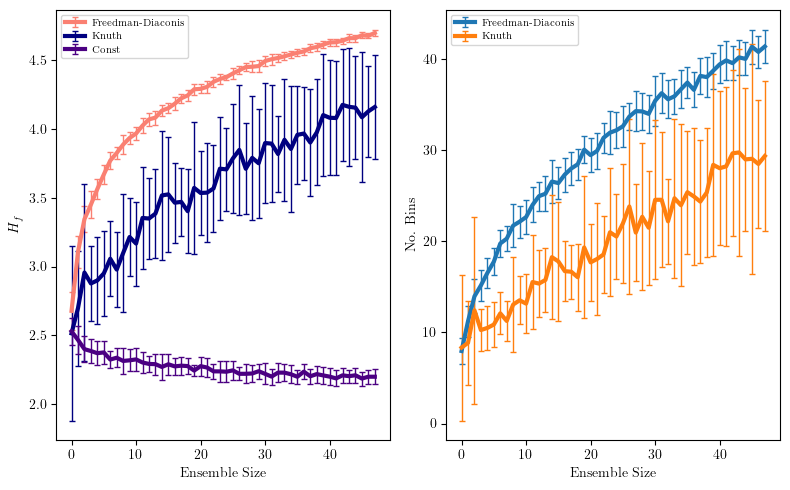

In [189]:
CAPSIZE = 2

fig, axs = plt.subplots(1,2, figsize=(8,5))
axs[0].errorbar(Ns, H_f_fd_bins.mean(axis=1), color='salmon',
             yerr=H_f_fd_bins.std(axis=1), linewidth=3, 
             elinewidth=1, capsize=CAPSIZE, label='Freedman-Diaconis')
axs[0].errorbar(Ns, H_f_knuth_bins.mean(axis=1), color='navy',
             yerr=H_f_knuth_bins.std(axis=1), linewidth=3, 
             elinewidth=1, capsize=CAPSIZE, label='Knuth')
axs[0].errorbar(Ns, H_f_const_bin.mean(axis=1), color='indigo',
             yerr=H_f_const_bin.std(axis=1), linewidth=3, 
             elinewidth=1, capsize=CAPSIZE, label='Const')
axs[0].set_ylabel("$H_f$")
axs[0].set_xlabel("Ensemble Size")
axs[0].legend(fontsize=7)

axs[1].errorbar(Ns, fd_bins.mean(axis=1), linewidth=3, 
             elinewidth=1, yerr=fd_bins.std(axis=1), capsize=CAPSIZE, label='Freedman-Diaconis')
axs[1].errorbar(Ns, knuth_bins.mean(axis=1), linewidth=3, 
             elinewidth=1, yerr=knuth_bins.std(axis=1), capsize=CAPSIZE, label='Knuth')
axs[1].set_xlabel("Ensemble Size")
axs[1].set_ylabel("No. Bins")
axs[1].legend(fontsize=7)

plt.tight_layout()

This plot shows that the estimated entropy of the ensemble increases as a consequence of scaling number of bins. In contrast, when the number of bins is kept constant, the entropy actually decreases as the ensemble size increases. The decrease is likely caused by the fact that increasingly many data points are being shoved into the same number of bins, making the empirical distribution more like a Gaussian. This shows that the choice of scaling number of bins contributes to a rise of entropy, and therefore justifies using the tiled version of $g(t)$ in the calculation of $\gamma_o$, so that it accounts for the effect of scaling bins.

# How do metrics change with ensemble size?

In [20]:
# my_lon=340; my_lat=45
my_lon=240; my_lat=-50
# my_lon=10; my_lat=-45
# my_lon, my_lat = 60, 0 
# my_lon, my_lat = 120, -45 # rho=0.4

In [21]:
NUM_SAMPLES_2 = 50
Ns = np.arange(len(f.n))

from joblib import Parallel, delayed

# --- Hoist everything that does not change inside the loop -------------------
# Pull this one gridpoint out of the cube ONCE, instead of doing a fresh
# xarray .sel on the full (n, time, lat, lon) cube every iteration.
# NaNs are kept as NaN and masked out later. Filling them with 0.0 plants a
# spike of identical values in the middle of the anomaly distribution, which
# KSG reads as a dense cluster.
f_pt = f.sel(lon=my_lon, lat=my_lat, method='nearest').psl.to_numpy().copy()
g_t = obs.sel(lon=my_lon, lat=my_lat, method='nearest').psl.to_numpy()

# Draw every member subset up front, WITHOUT replacement: permute each row and
# take the first n+1, so each sample holds n+1 distinct members. Seeded so the
# parallel section is reproducible; drop the seed for fresh draws.
rng = np.random.default_rng(0)
members = [rng.random((NUM_SAMPLES_2, len(Ns))).argsort(axis=1)[:, :n + 1] for n in Ns]


def corr_last(a, b):
    """Pearson correlation along the last axis, dropping pairwise NaNs."""
    a, b = np.broadcast_arrays(a, b)
    ok = ~(np.isnan(a) | np.isnan(b))
    a = np.where(ok, a, 0.0)
    b = np.where(ok, b, 0.0)
    cnt = ok.sum(-1)
    sa, sb = a.sum(-1), b.sum(-1)
    cov = (a * b).sum(-1) - sa * sb / cnt
    va = (a * a).sum(-1) - sa * sa / cnt
    vb = (b * b).sum(-1) - sb * sb / cnt
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(cnt > 2, cov / np.sqrt(va * vb), np.nan)


# --- Variance metrics: vectorised over all NUM_SAMPLES_2 samples at once -----
var_metrics = np.zeros((3, len(Ns), NUM_SAMPLES_2))
for i, n in enumerate(Ns):
    m = n + 1
    f_nt = f_pt[members[i]]                       # (sample, member, time)
    ok = ~np.isnan(f_nt)
    cnt = ok.sum(axis=1)                          # valid members per timestep
    with np.errstate(invalid='ignore'):
        s_t = np.where(cnt > 0,                   # (sample, time)
                       np.where(ok, f_nt, 0.0).sum(axis=1) / np.maximum(cnt, 1), np.nan)

    rho_o = corr_last(s_t, g_t[None, :])
    rho_m = np.sqrt(np.nanvar(s_t, axis=-1) / np.nanvar(f_nt, axis=-1).mean(axis=-1))

    if m >= 2:
        # Leave-one-out mean of the other members, NaN-aware: subtract each
        # member from the running sum and count, so no inner python loop.
        filled = np.where(ok, f_nt, 0.0)
        loo_sum = filled.sum(axis=1, keepdims=True) - filled
        loo_cnt = ok.sum(axis=1, keepdims=True) - ok
        with np.errstate(invalid='ignore', divide='ignore'):
            loo_s_t = np.where(loo_cnt > 0, loo_sum / loo_cnt, np.nan)
        rho_m_2 = np.nanmean(corr_last(f_nt, loo_s_t), axis=1)
    else:
        rho_m_2 = np.zeros(NUM_SAMPLES_2)

    var_metrics[:, i, :] = np.stack([rho_o, rho_m, rho_m_2])


# --- Info metrics ------------------------------------------------------------
# KSG is a k-nearest-neighbour estimator, so these cannot be vectorised, but
# every (n, sample) pair is independent -> spread them over all cores.
def info_metrics(n, mem):
    f_nt = f_pt[mem]
    ok = ~np.isnan(f_nt)
    cnt = ok.sum(axis=0)
    with np.errstate(invalid='ignore'):
        s_t = np.where(cnt > 0,
                       np.where(ok, f_nt, 0.0).sum(axis=0) / np.maximum(cnt, 1), np.nan)
    f_flat = f_nt[ok]                             # NaNs dropped, not zero-filled
    # Mask the tiled partners with the same mask so the pairs stay aligned.
    g_rep = np.tile(g_t, n + 1)[ok.ravel()]
    s_rep = np.tile(s_t, n + 1)[ok.ravel()]
    # I_gf : obs against each individual member, pooled over the members.
    # I_gs : obs against the ensemble mean itself, no tiling.
    valid = ~np.isnan(s_t)

    # I_sf_loo : leave-one-out. Each member against the mean of the OTHER
    # members, averaged over the subset -- the same structure as rho_m_2.
    m = n + 1
    if m >= 2:
        loo_sum = np.where(ok, f_nt, 0.0).sum(axis=0) - np.where(ok, f_nt, 0.0)
        loo_cnt = ok.sum(axis=0) - ok
        with np.errstate(invalid='ignore'):
            loo_s = np.where(loo_cnt > 0, loo_sum / np.maximum(loo_cnt, 1), np.nan)
        loo_vals = []
        for j in range(m):
            v = ok[j] & ~np.isnan(loo_s[j])
            if v.sum() > 3:
                loo_vals.append(im.mutual_information(loo_s[j][v], f_nt[j][v],
                                                      approach='metric', k=3))
        i_sf_loo = float(np.mean(loo_vals)) if loo_vals else np.nan
    else:
        i_sf_loo = np.nan                         # no "other members" at m = 1

    return (im.mutual_information(g_rep, f_flat, approach='metric', k=3),
            im.mutual_information(g_t[valid], s_t[valid], approach='metric', k=3),
            im.mutual_information(s_rep, f_flat, approach='metric', k=3),
            i_sf_loo,
            im.entropy(f_flat, approach='metric', k=3))


# Largest n first, so the slowest tasks are not left stranded at the end.
tasks = sorted(((i, n, s) for i, n in enumerate(Ns) for s in range(NUM_SAMPLES_2)),
               key=lambda t: -t[1])
results = list(tqdm(
    Parallel(n_jobs=-1, batch_size=4, return_as="generator")(
        delayed(info_metrics)(n, members[i][s]) for i, n, s in tasks),
    total=len(tasks)))

I_gf = np.zeros((len(Ns), NUM_SAMPLES_2))
I_gs = np.zeros((len(Ns), NUM_SAMPLES_2))
I_sf = np.zeros((len(Ns), NUM_SAMPLES_2))
I_sf_loo = np.zeros((len(Ns), NUM_SAMPLES_2))
H_f = np.zeros((len(Ns), NUM_SAMPLES_2))
for (i, n, sample), (i_gf, i_gs, i_sf, i_loo, h_f) in zip(tasks, results):
    (I_gf[i, sample], I_gs[i, sample], I_sf[i, sample],
     I_sf_loo[i, sample], H_f[i, sample]) = i_gf, i_gs, i_sf, i_loo, h_f

# H(g_t) depends on neither n nor sample, so estimate it once and broadcast.
H_g = np.full((len(Ns), NUM_SAMPLES_2), im.entropy(g_t, approach='metric', k=3))


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2450/2450 [00:21<00:00, 112.99it/s]


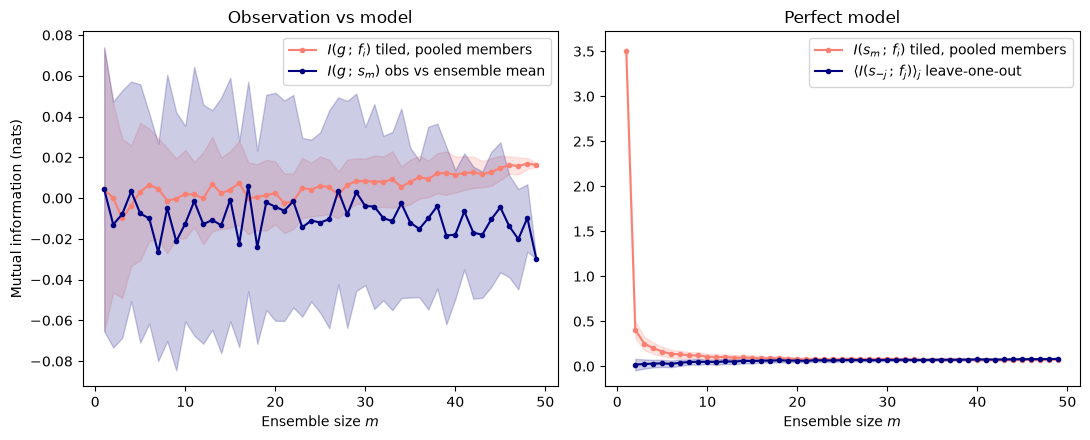

In [22]:
# Left : I(g ; f) two ways.  Right : I(s ; f) two ways.
# Line is the mean over the NUM_SAMPLES_2 samples, shading is +/- 1 sigma.
m_axis = Ns + 1

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)


def band(ax, x, arr, color, label):
    mu, sd = arr.mean(axis=1), arr.std(axis=1)
    ax.plot(x, mu, "o-", ms=3, color=color, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.2)


band(axs[0], m_axis, I_gf, "salmon", r'$I(g\,;\,f_i)$ tiled, pooled members')
band(axs[0], m_axis, I_gs, "navy", r'$I(g\,;\,s_m)$ obs vs ensemble mean')
axs[0].set_ylabel(r'Mutual information (nats)')
axs[0].set_title(r'Observation vs model')

band(axs[1], m_axis, I_sf, "salmon", r'$I(s_m\,;\,f_i)$ tiled, pooled members')
# leave-one-out is undefined at m = 1, so start that curve at m = 2
band(axs[1], m_axis[1:], I_sf_loo[1:], "navy",
     r'$\langle I(s_{-j}\,;\,f_j)\rangle_j$ leave-one-out')
axs[1].set_title(r'Perfect model')

for ax in axs:
    ax.set_xlabel(r'Ensemble size $m$')
    ax.legend()
fig.tight_layout()


In [23]:
gam_o = I_gf / H_g 
gam_m = I_sf / H_f

lam_o = np.sqrt(1 - np.exp(-2*I_gf))
lam_os = np.sqrt(1 - np.exp(-2*I_gs))
lam_m = np.sqrt(1 - np.exp(-2*I_sf))

rho_o = var_metrics[0]
rho_m = var_metrics[1]
rho_m_2 = var_metrics[2]

/var/folders/mq/460sdntn3jn1gkn5pz_4453m0000gn/T/ipykernel_96583/4080904664.py:4: RuntimeWarning: invalid value encountered in sqrt
  lam_o = np.sqrt(1 - np.exp(-2*I_gf))
/var/folders/mq/460sdntn3jn1gkn5pz_4453m0000gn/T/ipykernel_96583/4080904664.py:5: RuntimeWarning: invalid value encountered in sqrt
  lam_os = np.sqrt(1 - np.exp(-2*I_gs))


<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/var/folders/mq/460sdntn3jn1gkn5pz_4453m0000gn/T/ipykernel_96583/3757435140.py:12: SyntaxWarning: invalid escape sequence '\g'
  gam_ax.errorbar(Ns, gam_o.mean(axis=1), yerr=gam_o.std(axis=1)/2, color='salmon', label='$\gamma_o$')
/var/folders/mq/460sdntn3jn1gkn5pz_4453m0000gn/T/ipykernel_96583/3757435140.py:13: SyntaxWarning: invalid escape sequence '\g'
  gam_ax.errorbar(Ns, gam_m.mean(axis=1), yerr=gam_m.std(axis=1)/2, color='navy', label='$\gamma_m$')
/var/folders/mq/460sdntn3jn1gk

Lon=240 E, Lat=-50 N


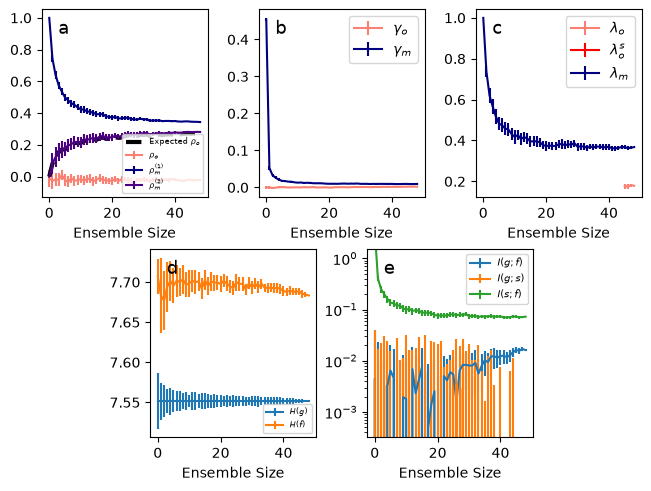

In [24]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(layout="constrained")
gs = GridSpec(4, 6, figure=fig)
rho_ax = fig.add_subplot(gs[0:2,0:2])
gam_ax = fig.add_subplot(gs[0:2,2:4])
lam_ax = fig.add_subplot(gs[0:2,4:6])
H_ax = fig.add_subplot(gs[2:4,1:3])
I_ax = fig.add_subplot(gs[2:4,3:5])

# fig, axs = plt.subplots(2,2, figsize=(5.5, 6))
gam_ax.errorbar(Ns, gam_o.mean(axis=1), yerr=gam_o.std(axis=1)/2, color='salmon', label='$\gamma_o$')
gam_ax.errorbar(Ns, gam_m.mean(axis=1), yerr=gam_m.std(axis=1)/2, color='navy', label='$\gamma_m$')
# axs[0,0].set_yscale("log")
# axs[0,0].set_yscale("log")
# axs[0,0].legend()
# axs[0,0].set_ylim([0,1.1])

lam_ax.errorbar(Ns, lam_o.mean(axis=1), yerr=lam_o.std(axis=1)/2,color='salmon',  label='$\lambda_o$')
lam_ax.errorbar(Ns, lam_os.mean(axis=1), yerr=lam_os.std(axis=1)/2,color='red',  label='$\lambda_o^s$')
lam_ax.errorbar(Ns, lam_m.mean(axis=1), yerr=lam_m.std(axis=1)/2, color='navy', label='$\lambda_m$')
# axs[0,1].legend()
# axs[0,1].set_ylim([0,1.1])


rho_ax.errorbar(Ns, rho_o.mean(axis=1), yerr=rho_o.std(axis=1)/2, color='salmon', label=r'$\rho_o$')
rho_ax.errorbar(Ns, rho_m.mean(axis=1), yerr=rho_m.std(axis=1)/2, color='navy', label=r'$\rho_m^{(1)}$')
rho_ax.plot(Ns, rho_m_2.mean(axis=1) / np.sqrt(1 + rho_m_2.mean(axis=1)**2), '--', linewidth=3, color='black', label=r'Expected $\rho_o$')
rho_ax.errorbar(Ns, rho_m_2.mean(axis=1), yerr=rho_m_2.std(axis=1)/2, color='indigo', label=r'$\rho_m^{(2)}$')
# axs[1,0].legend()
# axs[1,0].set_ylim([0,1.1])


I_ax.errorbar(Ns, I_gf.mean(axis=1), yerr=I_gf.std(axis=1)/2, label='$I(g;f)$')
I_ax.errorbar(Ns, I_gs.mean(axis=1), yerr=I_gs.std(axis=1)/2, label='$I(g;s)$')
I_ax.errorbar(Ns, I_sf.mean(axis=1), yerr=I_sf.std(axis=1)/2, label='$I(s;f)$')
I_ax.set_yscale('log')

H_ax.errorbar(Ns, H_g.mean(axis=1), yerr=I_gf.std(axis=1)/2, label='$H(g)$')
H_ax.errorbar(Ns, H_f.mean(axis=1), yerr=I_sf.std(axis=1)/2, label='$H(f)$')
# axs[1,1].legend()

axs = [rho_ax, gam_ax, lam_ax, H_ax, I_ax]
PLOT_TITLES = [r"a", r"b", r"c", r"d", r"e"]

# plt.tight_layout()
for i in range(len(axs)):
    ax = axs[i]
    if i==0:
        ax.legend(fontsize=6, loc='lower right')
    elif i==4:
        ax.legend(fontsize=7, loc='upper right')
    else:
        ax.legend()
    ax.set_xlabel("Ensemble Size")
    ax.text(0.1, 0.87, PLOT_TITLES[i], transform=ax.transAxes, fontsize=13)
H_ax.legend(loc='lower right', fontsize=6)
I_ax.set_ylim([0, 1.5])
print(f"Lon={np.round(my_lon,3)} E, Lat={np.round(my_lat,3)} N")

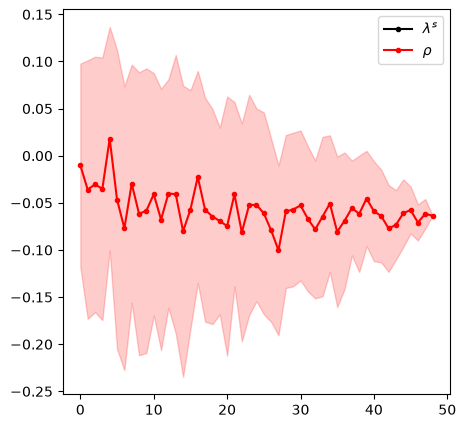

In [25]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))


def band(ax, x, arr, color, label):
    mu, sd = arr.mean(axis=1), arr.std(axis=1)
    ax.plot(x, mu, "o-", ms=3, color=color, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.2)

band(axs, Ns, lam_os/lam_m, 'k', '$\\lambda^s$')
band(axs, Ns, rho_o/rho_m, 'r', '$\\rho$')
axs.legend()

In [146]:
from scipy.stats import skew, kurtosis
from numpy import nanmean, nanvar

def compute_stat_moments(lon, lat, plot=False):
    flat_s = s.sel(lon=lon, lat=lat, method='nearest').psl.to_numpy().flatten()
    flat_obs = obs.sel(lon=lon, lat=lat, method='nearest').psl.to_numpy().flatten()
    flat_obs = flat_obs[~np.isnan(flat_obs)]
    flat_f = f.sel(lon=lon, lat=lat, method='nearest').psl.to_numpy().flatten()
    flat_s = flat_s[~np.isnan(flat_s)]
    flat_obs = flat_obs[~np.isnan(flat_obs)]
    flat_f = flat_f[~np.isnan(flat_f)]

    s_mean, s_var, s_skew, s_kurt = np.round(nanmean(flat_s), 3), np.round(nanvar(flat_s),3), np.round(skew(flat_s),3), np.round(kurtosis(flat_s),3)
    obs_mean, obs_var, obs_skew, obs_kurt = np.round(nanmean(flat_obs), 3), np.round(nanvar(flat_obs),3), np.round(skew(flat_obs),3), np.round(kurtosis(flat_obs),3)
    f_mean, f_var, f_skew, f_kurt = np.round(nanmean(flat_f), 3), np.round(nanvar(flat_f),3), np.round(skew(flat_f),3), np.round(kurtosis(flat_f),3)
    avg_f_var = 0
    for i in range(len(f.n)):
        f_i = f.sel(n=i, lon=lon, lat=lat, method='nearest').psl.to_numpy()
        avg_f_var += nanvar(f_i)/len(f.n)
    print(f"Lon={lon}, Lat={lat}")
    print(f"Sig -- mean={s_mean} | var={s_var} | skew={s_skew} | kurt={s_kurt}")
    print(f"Obs -- mean={obs_mean} | var={obs_var} | skew={obs_skew} | kurt={obs_kurt}")
    print(f"Ens -- mean={f_mean} | avgvar={avg_f_var} | var={f_var} | skew={f_skew} | kurt={f_kurt}")
    print(f"Model SNR = {np.sqrt(s_var / avg_f_var)}")
    print(f"Obs SNR = {np.sqrt(obs_var / avg_f_var)}")
    if plot:
        s_bins, s_edges = np.histogram(flat_s, density=True)
        obs_bins, obs_edges = np.histogram(flat_obs, density=True)
        f_bins, f_edges = np.histogram(flat_f, density=True)
        plt.figure()
        plt.stairs(s_bins, s_edges, fill=True, alpha=0.5, label='Signal')
        plt.stairs(obs_bins, obs_edges, fill=True, alpha=0.5, label='HadSLP2')
        plt.stairs(f_bins, f_edges, fill=True, alpha=0.5, label='Ensemble')
        plt.legend()
        plt.xlim([-2000, 2000])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0));

Lon=120, Lat=-45
Sig -- mean=1.094 | var=167118.739 | skew=-0.103 | kurt=-1.247
Obs -- mean=0.0 | var=82417.315 | skew=-0.292 | kurt=-0.197
Ens -- mean=-0.0 | avgvar=356926.598917905 | var=358986.967 | skew=-0.347 | kurt=-0.188
Model SNR = 0.6842630961565329
Obs SNR = 0.48052918984680504


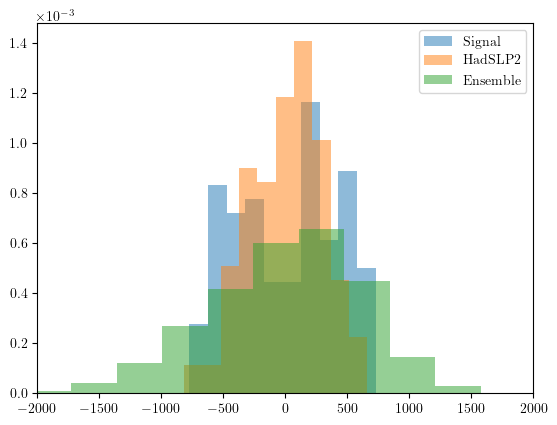

In [212]:
compute_stat_moments(120, -45, plot=True) # rho=0.4

In [184]:
compute_stat_moments(60, 0, plot=False) # rho=1.6

Lon=60, Lat=0
Sig -- mean=-0.074 | var=2000.987 | skew=-0.042 | kurt=-1.347
Obs -- mean=-0.0 | var=4208.045 | skew=-0.322 | kurt=-0.467
Ens -- mean=-0.0 | avgvar=10047.76499394655 | var=10034.633 | skew=-0.144 | kurt=-0.103
Model SNR = 0.44625942255541956
Obs SNR = 0.6471507417543502


# How does kurtosis relate to the SNP ($\rho>1$)? 
(Work in Progress)

In [219]:
# TODO: Make a map of the kurtosis!
def make_stat_map():
    _, y_len, x_len = s.psl.shape
    kurt = np.zeros((3, y_len, x_len))
    var = np.zeros((3, y_len, x_len))
    for y in tqdm(range(y_len)):
        for x in range(x_len):
            flat_s = s.isel(lon=x, lat=y).psl.to_numpy().flatten()
            flat_obs = obs.isel(lon=x, lat=y).psl.to_numpy().flatten()
            flat_obs = flat_obs[~np.isnan(flat_obs)]
            flat_f = f.isel(lon=x, lat=y).psl.to_numpy().flatten()
            flat_s = flat_s[~np.isnan(flat_s)]
            flat_obs = flat_obs[~np.isnan(flat_obs)]
            flat_f = flat_f[~np.isnan(flat_f)]

            s_mean, s_var, s_skew, s_kurt = np.round(nanmean(flat_s), 3), np.round(nanvar(flat_s),3), np.round(skew(flat_s),3), np.round(kurtosis(flat_s),3)
            obs_mean, obs_var, obs_skew, obs_kurt = np.round(nanmean(flat_obs), 3), np.round(nanvar(flat_obs),3), np.round(skew(flat_obs),3), np.round(kurtosis(flat_obs),3)
            f_mean, f_var, f_skew, f_kurt = np.round(nanmean(flat_f), 3), np.round(nanvar(flat_f),3), np.round(skew(flat_f),3), np.round(kurtosis(flat_f),3)
            
            var[:,y,x] = s_var, obs_var, f_var
            kurt[:,y,x] = s_kurt, obs_kurt, f_kurt
    return var, kurt

In [220]:
var_arr, kurt_arr = make_stat_map()

100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:26<00:00,  2.39it/s]


In [225]:
def plot_stats_over_earth(arr, vmin=0, vmax=2):
    fig, axs = plt.subplots(1,3, figsize=(10,10), subplot_kw=dict(projection=ccrs.PlateCarree()))

    normalizer = Normalize(vmin, vmax)
    im = cm.ScalarMappable(norm=normalizer, cmap='PuBu')
    axs[0].imshow(np.abs(arr[0]), norm=normalizer, cmap='PuBu', origin='lower', extent=(0, 360, -90, 90), transform=ccrs.PlateCarree())
    axs[1].imshow(np.abs(arr[1]), norm=normalizer, cmap='PuBu', origin='lower', extent=(0, 360, -90, 90), transform=ccrs.PlateCarree())
    axs[2].imshow(np.abs(arr[2]), norm=normalizer, cmap='PuBu', origin='lower', extent=(0, 360, -90, 90), transform=ccrs.PlateCarree())
    fig.colorbar(im, ax=(axs[0], axs[1], axs[2]), fraction=0.008, pad=0.02)

    titles = ["Signal", "Observation", "Ensemble"]
    for i in range(3):
        axs[i].coastlines()
        axs[i].set_title(titles[i])

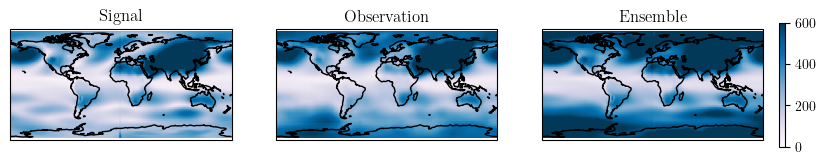

In [230]:
plot_stats_over_earth(np.sqrt(var_arr), vmin=0, vmax=600)

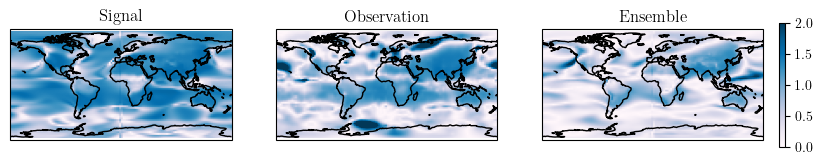

In [231]:
plot_stats_over_earth(kurt_arr)

# But the ratio of signal-observation variances has a good correlation with $\rho>1$...

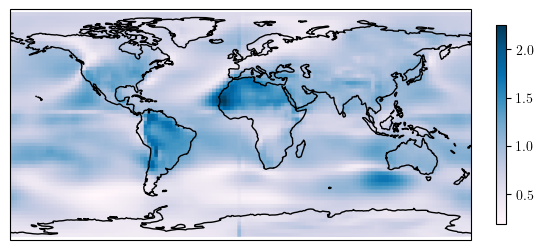

In [247]:
fig, axs = plt.subplots(1,1, subplot_kw=dict(projection=ccrs.PlateCarree()))
im = axs.imshow(np.sqrt(var_arr[0]/var_arr[1]), cmap='PuBu', origin='lower', extent=(0, 360, -90, 90), transform=ccrs.PlateCarree())
plt.colorbar(im, fraction=0.02)
axs.coastlines()